# **Deep Learning Lab: Transfer Learning**

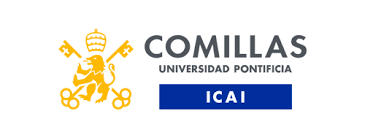

***

## Import packages

In [1]:
from cnn import CNN
import torchvision
from cnn import load_data
from cnn import load_model_weights
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import wandb

In [2]:
# Optional: install W&B once in this environment
# %pip install wandb
wandb.login(relogin=False)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: javiag_ (javi_paula_julia). Use `wandb login --relogin` to force relogin


True

## Model and data loading

In [3]:
# Pytorch has many pre-trained models that can be used for transfer learning
classification_models = torchvision.models.list_models(module=torchvision.models)
print(classification_models)

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'googlenet', 'inception_v3', 'maxvit_t', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_32gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_x_8gf', 'regnet_y_128gf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_32gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_32x8d', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'squeezenet1_0

In [4]:
# Load data and model 
train_dir = './dataset/training'
valid_dir = './dataset/validation'

train_loader, valid_loader, num_classes = load_data(train_dir, 
                                                    valid_dir, 
                                                    batch_size=32, 
                                                    img_size=224)

model1 = CNN(torchvision.models.efficientnet_v2_s(weights='DEFAULT'), num_classes, unfreezed_layers=0)
model2 = CNN(torchvision.models.convnext_small(weights='DEFAULT'), num_classes, unfreezed_layers=0)
model3 = CNN(torchvision.models.swin_t(weights='DEFAULT'), num_classes, unfreezed_layers=0)

/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


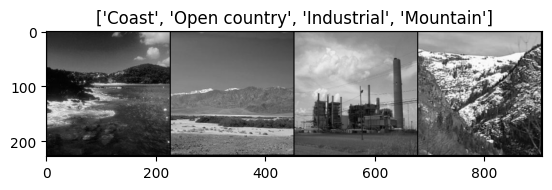

In [5]:
# Visualize a few images
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a few random images
random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)
inputs = []
classes = []
for i in random_indices:
    inputs.append(valid_loader.dataset[i][0])
    classes.append(valid_loader.dataset[i][1])
out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[classnames[x] for x in classes])

## Train

### Baseline

In [6]:
configs = [
    {"model": model1, "name": "EfficientNetV2-S", "lr": 1e-3},
    {"model": model2, "name": "ConvNeXt-Small",   "lr": 1e-3},
    {"model": model3, "name": "Swin-T",           "lr": 1e-3},
]

criterion = nn.CrossEntropyLoss()

for cfg in configs:
    optimizer = torch.optim.AdamW(cfg["model"].parameters(), lr=cfg["lr"], weight_decay=0.01)
    wandb_config = {
        "dataset": "Scene Classification",
        "model": cfg["name"],
        "epochs": 8,
        "unfrozen_layers": 0,
        "lr": cfg["lr"],
        "optimizer": "AdamW",
        "weight_decay": 0.01,
    }
    history = cfg["model"].train_model(
        train_loader, valid_loader, optimizer, criterion,
        epochs=8, use_wandb=True, wandb_config=wandb_config, architecture=cfg["name"],
        run_name=f"{cfg['name']}_baseline_lr{cfg['lr']}_frozen"
    )

Epoch 1/8 - Train Loss: 1.9475, Train Accuracy: 0.4573
Epoch 1/8 - Validation Loss: 1.3922, Validation Accuracy: 0.7020
Epoch 2/8 - Train Loss: 1.3149, Train Accuracy: 0.6375
Epoch 2/8 - Validation Loss: 1.0258, Validation Accuracy: 0.7480
Epoch 3/8 - Train Loss: 1.1436, Train Accuracy: 0.6516
Epoch 3/8 - Validation Loss: 0.8620, Validation Accuracy: 0.7747
Epoch 4/8 - Train Loss: 1.0168, Train Accuracy: 0.6888
Epoch 4/8 - Validation Loss: 0.8195, Validation Accuracy: 0.7727
Epoch 5/8 - Train Loss: 0.9762, Train Accuracy: 0.6945
Epoch 5/8 - Validation Loss: 0.7551, Validation Accuracy: 0.7820
Epoch 6/8 - Train Loss: 0.9532, Train Accuracy: 0.7062
Epoch 6/8 - Validation Loss: 0.6901, Validation Accuracy: 0.7873
Epoch 7/8 - Train Loss: 0.9020, Train Accuracy: 0.7129
Epoch 7/8 - Validation Loss: 0.6962, Validation Accuracy: 0.7913
Epoch 8/8 - Train Loss: 0.8996, Train Accuracy: 0.7156
Epoch 8/8 - Validation Loss: 0.6373, Validation Accuracy: 0.8060


epoch,▁▂▃▄▅▆▇█
train/accuracy,▁▆▆▇▇███
train/loss,█▄▃▂▂▁▁▁
valid/accuracy,▁▄▆▆▆▇▇█
valid/loss,█▅▃▃▂▁▂▁
epoch,8
train/accuracy,0.71558
train/loss,0.8996
valid/accuracy,0.806
valid/loss,0.63725


Epoch 1/8 - Train Loss: 2.3484, Train Accuracy: 0.3782
Epoch 1/8 - Validation Loss: 2.1463, Validation Accuracy: 0.4887
Epoch 2/8 - Train Loss: 1.8740, Train Accuracy: 0.5936
Epoch 2/8 - Validation Loss: 1.7616, Validation Accuracy: 0.6573
Epoch 3/8 - Train Loss: 1.5768, Train Accuracy: 0.6734
Epoch 3/8 - Validation Loss: 1.4882, Validation Accuracy: 0.7200
Epoch 4/8 - Train Loss: 1.3922, Train Accuracy: 0.7052
Epoch 4/8 - Validation Loss: 1.2907, Validation Accuracy: 0.7973
Epoch 5/8 - Train Loss: 1.2456, Train Accuracy: 0.7417
Epoch 5/8 - Validation Loss: 1.1513, Validation Accuracy: 0.8093
Epoch 6/8 - Train Loss: 1.1367, Train Accuracy: 0.7598
Epoch 6/8 - Validation Loss: 1.0427, Validation Accuracy: 0.8327
Epoch 7/8 - Train Loss: 1.0594, Train Accuracy: 0.7682
Epoch 7/8 - Validation Loss: 0.9544, Validation Accuracy: 0.8353
Epoch 8/8 - Train Loss: 1.0157, Train Accuracy: 0.7658
Epoch 8/8 - Validation Loss: 0.8810, Validation Accuracy: 0.8547


epoch,▁▂▃▄▅▆▇█
train/accuracy,▁▅▆▇████
train/loss,█▆▄▃▂▂▁▁
valid/accuracy,▁▄▅▇▇███
valid/loss,█▆▄▃▂▂▁▁
epoch,8
train/accuracy,0.76583
train/loss,1.01569
valid/accuracy,0.85467
valid/loss,0.88099


Epoch 1/8 - Train Loss: 1.6120, Train Accuracy: 0.5923
Epoch 1/8 - Validation Loss: 0.8054, Validation Accuracy: 0.8540
Epoch 2/8 - Train Loss: 0.8949, Train Accuracy: 0.7648
Epoch 2/8 - Validation Loss: 0.5017, Validation Accuracy: 0.8813
Epoch 3/8 - Train Loss: 0.7374, Train Accuracy: 0.7893
Epoch 3/8 - Validation Loss: 0.4090, Validation Accuracy: 0.8787
Epoch 4/8 - Train Loss: 0.6694, Train Accuracy: 0.8064
Epoch 4/8 - Validation Loss: 0.3469, Validation Accuracy: 0.9040
Epoch 5/8 - Train Loss: 0.6179, Train Accuracy: 0.8127
Epoch 5/8 - Validation Loss: 0.3168, Validation Accuracy: 0.9087
Epoch 6/8 - Train Loss: 0.5671, Train Accuracy: 0.8312
Epoch 6/8 - Validation Loss: 0.3048, Validation Accuracy: 0.8993
Epoch 7/8 - Train Loss: 0.5771, Train Accuracy: 0.8258
Epoch 7/8 - Validation Loss: 0.2900, Validation Accuracy: 0.9040
Epoch 8/8 - Train Loss: 0.5470, Train Accuracy: 0.8305
Epoch 8/8 - Validation Loss: 0.2750, Validation Accuracy: 0.9107


epoch,▁▂▃▄▅▆▇█
train/accuracy,▁▆▇▇▇███
train/loss,█▃▂▂▁▁▁▁
valid/accuracy,▁▄▄▇█▇▇█
valid/loss,█▄▃▂▂▁▁▁
epoch,8
train/accuracy,0.83049
train/loss,0.54701
valid/accuracy,0.91067
valid/loss,0.27499


### Fine-tuning (Swin-T)

In [ ]:
# Fine-tuning de Swin-T en dos fases: warmup + unfreeze parcial
criterion = nn.CrossEntropyLoss()

# Fase 1: entrenar solo la cabeza de clasificación
for p in model3.feature_extractor.parameters():
    p.requires_grad = False
for p in model3.classifier.parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW(
    model3.classifier.parameters(),
    lr=1e-3,
    weight_decay=0.01
)

history_swin_warmup = model3.train_model(
    train_loader, valid_loader, optimizer, criterion,
    epochs=3,
    run_name="Swin-T_warmup_head_only",
    use_wandb=True,
    wandb_config={
        "dataset": "Scene Classification",
        "model": "Swin-T",
        "phase": "warmup",
        "unfrozen_layers": 0,
        "lr_head": 1e-3,
        "optimizer": "AdamW",
        "weight_decay": 0.01,
    },
    architecture="Swin-T",
)

# Fase 2: descongelar las ultimas 2 capas del extractor
for p in model3.feature_extractor.parameters():
    p.requires_grad = False
for layer in list(model3.feature_extractor.children())[-2:]:
    for p in layer.parameters():
        p.requires_grad = True
for p in model3.classifier.parameters():
    p.requires_grad = True

backbone_params = [p for p in model3.feature_extractor.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    [
        {"params": model3.classifier.parameters(), "lr": 3e-4},
        {"params": backbone_params, "lr": 1e-5},
    ],
    weight_decay=0.01,
    )

history_swin_ft = model3.train_model(
    train_loader, valid_loader, optimizer, criterion,
    epochs=8,
    run_name="Swin-T_finetune_last2",
    use_wandb=True,
    wandb_config={
        "dataset": "Scene Classification",
        "model": "Swin-T",
        "phase": "finetune",
        "unfrozen_layers": 2,
        "lr_head": 3e-4,
        "lr_backbone": 1e-5,
        "optimizer": "AdamW",
        "weight_decay": 0.01,
    },
    architecture="Swin-T",
)

Epoch 1/3 - Train Loss: 0.5494, Train Accuracy: 0.8312
Epoch 1/3 - Validation Loss: 0.2657, Validation Accuracy: 0.9120


In [7]:
model1.save('convnext_base-8epoch')

In [8]:
model2.save('efficientnet_b0-8epoch')

In [9]:
model3.save('resnet50-8epoch')

## Predict

#### Load model

In [ ]:
# Load ConvNeXt-Base model for prediction
w1 = load_model_weights('convnext_base-8epoch')
m1 = CNN(torchvision.models.convnext_base(weights='DEFAULT'), num_classes, unfreezed_layers=0)
m1.load_state_dict(w1)
print('ConvNeXt-Base loaded')

In [ ]:
# Load EfficientNet-B0 model for prediction
w2 = load_model_weights('efficientnet_b0-8epoch')
m2 = CNN(torchvision.models.efficientnet_b0(weights='DEFAULT'), num_classes, unfreezed_layers=0)
m2.load_state_dict(w2)
print('EfficientNet-B0 loaded')

In [ ]:
# Load ResNet50 model for prediction
w3 = load_model_weights('resnet50-8epoch')
m3 = CNN(torchvision.models.resnet50(weights='DEFAULT'), num_classes, unfreezed_layers=0)
m3.load_state_dict(w3)
print('ResNet50 loaded')

## Results

In [ ]:
# Predict with ConvNeXt-Base
predicted_labels_m1 = m1.predict(valid_loader)
print('ConvNeXt-Base predictions:', len(predicted_labels_m1))

In [ ]:
# Predict with EfficientNet-B0
predicted_labels_m2 = m2.predict(valid_loader)
print('EfficientNet-B0 predictions:', len(predicted_labels_m2))

In [ ]:
# Predict with ResNet50
predicted_labels_m3 = m3.predict(valid_loader)
print('ResNet50 predictions:', len(predicted_labels_m3))

In [ ]:
# Visualize ConvNeXt-Base predictions
if 'random_indices' not in globals():
    random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)
inputs = [valid_loader.dataset[i][0] for i in random_indices]
pred_classes = [predicted_labels_m1[i] for i in random_indices]
out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[f"ConvNeXt-Base: {classnames[x]}" for x in pred_classes])

In [ ]:
# Visualize EfficientNet-B0 predictions (same images)
inputs = [valid_loader.dataset[i][0] for i in random_indices]
pred_classes = [predicted_labels_m2[i] for i in random_indices]
out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[f"EfficientNet-B0: {classnames[x]}" for x in pred_classes])

In [ ]:
# Visualize ResNet50 predictions (same images)
inputs = [valid_loader.dataset[i][0] for i in random_indices]
pred_classes = [predicted_labels_m3[i] for i in random_indices]
out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[f"ResNet50: {classnames[x]}" for x in pred_classes])